In [3]:
import kagglehub
import os
import imageio
import matplotlib.pyplot as plt
import numpy as np


In [4]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


Loaded: NORMAL2-IM-0336-0001.jpeg
Shape: (941, 1612)
Dtype: uint8


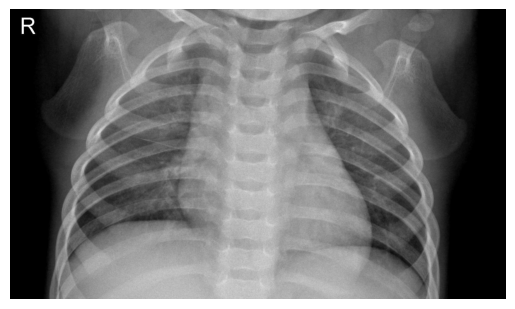

In [5]:
DIR = os.path.join(path, "chest_xray", "test", "NORMAL")

# Pick the first available image
filename = os.listdir(DIR)[0]
xray_image = imageio.v3.imread(os.path.join(DIR, filename))

print("Loaded:", filename)
print("Shape:", xray_image.shape)
print("Dtype:", xray_image.dtype)

fig, ax = plt.subplots()
ax.imshow(xray_image, cmap="gray")
ax.set_axis_off()
plt.show()

In [7]:
from PIL import Image

num_imgs = 9
target_size = (256, 256)  # resize all images to the same shape

filenames = os.listdir(DIR)[:num_imgs]
combined_xray_images = np.array([
    np.array(Image.open(os.path.join(DIR, f)).resize(target_size).convert("L"))
    for f in filenames
])

print(combined_xray_images.shape)  # expected: (9, 256, 256)

(9, 256, 256)


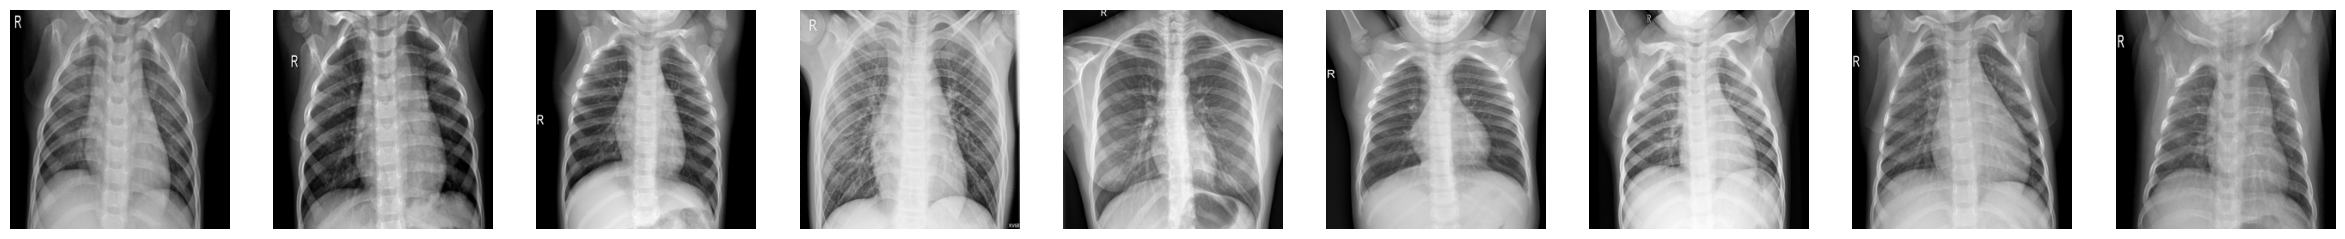

In [12]:
fig , axes = plt.subplots(nrows=1 , ncols=num_imgs, figsize=(30,30))

for img, ax in zip(combined_xray_images, axes):
    ax.imshow(img, cmap="gray")
    ax.set_axis_off()

In [15]:
GIF_PATH = "/tmp/xray_image.gif"
imageio.mimwrite(GIF_PATH, combined_xray_images, format=".gif", duration=1000)

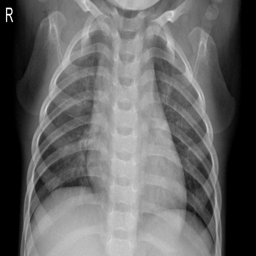

In [14]:
from IPython.display import Image, display
display(Image(filename=GIF_PATH))

In [16]:
from scipy import ndimage

xray_image_laplace_gaussian = ndimage.gaussian_laplace(xray_image, sigma=1)

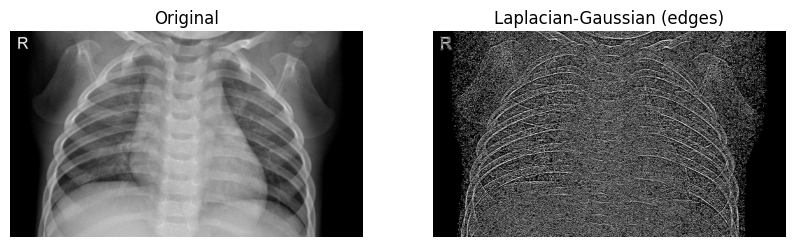

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 10))

axes[0].set_title("Original")
axes[0].imshow(xray_image, cmap="gray")
axes[1].set_title("Laplacian-Gaussian (edges)")
axes[1].imshow(xray_image_laplace_gaussian, cmap="gray")
for i in axes:
    i.axis("off")

Exception ignored in: <function PluginV3.__del__ at 0x7c7cf24d1bc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/imageio/core/v3_plugin_api.py", line 370, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py", line 145, in close
    self._flush_writer()
  File "/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py", line 486, in _flush_writer
    primary_image.save(self._request.get_file(), **self.save_args)
                       ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/imageio/core/request.py", line 493, in get_file
    self._file = open(self.filename, "wb")
                 ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 30] Read-only file system: '/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/xray_image.gif'


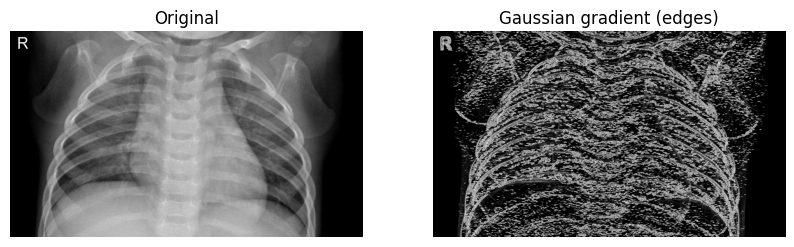

In [19]:
x_ray_image_gaussian_gradient = ndimage.gaussian_gradient_magnitude(xray_image, sigma=2)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 10))

axes[0].set_title("Original")
axes[0].imshow(xray_image, cmap="gray")
axes[1].set_title("Gaussian gradient (edges)")
axes[1].imshow(x_ray_image_gaussian_gradient, cmap="gray")
for i in axes:
    i.axis("off")

In [20]:
fourier_gaussian = ndimage.fourier_gaussian(xray_image, sigma=0.05)

x_prewitt = ndimage.prewitt(fourier_gaussian, axis=0)
y_prewitt = ndimage.prewitt(fourier_gaussian, axis=1)

xray_image_canny = np.hypot(x_prewitt, y_prewitt)

xray_image_canny *= 255.0 / np.max(xray_image_canny)

print("The data type - ", xray_image_canny.dtype)

The data type -  float64


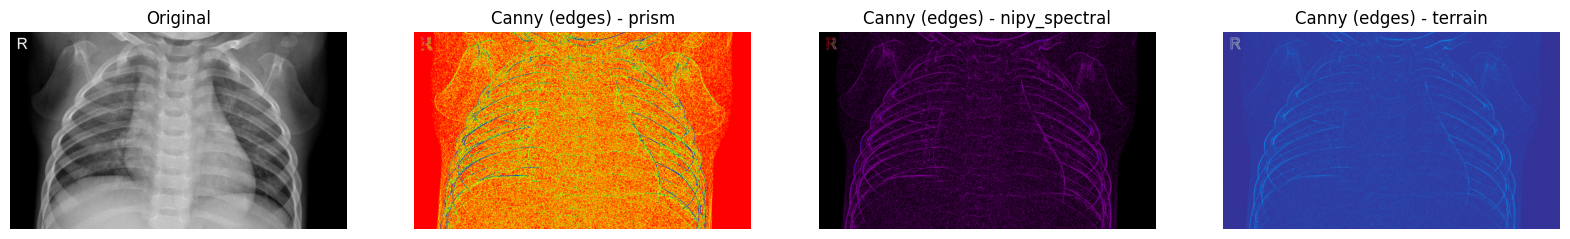

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 15))

axes[0].set_title("Original")
axes[0].imshow(xray_image, cmap="gray")
axes[1].set_title("Canny (edges) - prism")
axes[1].imshow(xray_image_canny, cmap="prism")
axes[2].set_title("Canny (edges) - nipy_spectral")
axes[2].imshow(xray_image_canny, cmap="nipy_spectral")
axes[3].set_title("Canny (edges) - terrain")
axes[3].imshow(xray_image_canny, cmap="terrain")
for i in axes:
    i.axis("off")